In [1]:
!pip install datasets

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]


=== Active Learning Iteration 1 ===
Epoch 1 Loss: 0.6887
Epoch 2 Loss: 0.6684
Epoch 3 Loss: 0.6816
Epoch 4 Loss: 0.5586
Epoch 5 Loss: 0.5364
Validation Accuracy: 50.92%
Total labeled samples after acquisition: 100

=== Active Learning Iteration 2 ===
Epoch 1 Loss: 0.6231
Epoch 2 Loss: 0.5004
Epoch 3 Loss: 0.3564
Epoch 4 Loss: 0.3191
Epoch 5 Loss: 0.2692
Validation Accuracy: 55.73%
Total labeled samples after acquisition: 150

=== Active Learning Iteration 3 ===
Epoch 1 Loss: 0.2920
Epoch 2 Loss: 0.1733
Epoch 3 Loss: 0.1036
Epoch 4 Loss: 0.0647
Epoch 5 Loss: 0.0309
Validation Accuracy: 69.38%
Total labeled samples after acquisition: 200

=== Active Learning Iteration 4 ===
Epoch 1 Loss: 0.2466
Epoch 2 Loss: 0.1139
Epoch 3 Loss: 0.0629
Epoch 4 Loss: 0.0524
Epoch 5 Loss: 0.0174
Validation Accuracy: 73.85%
Total labeled samples after acquisition: 250

=== Active Learning Iteration 5 ===
Epoch 1 Loss: 0.2121
Epoch 2 Loss: 0.0519
Epoch 3 Loss: 0.0198
Epoch 4 Loss: 0.0117
Epoch 5 Loss: 0.006

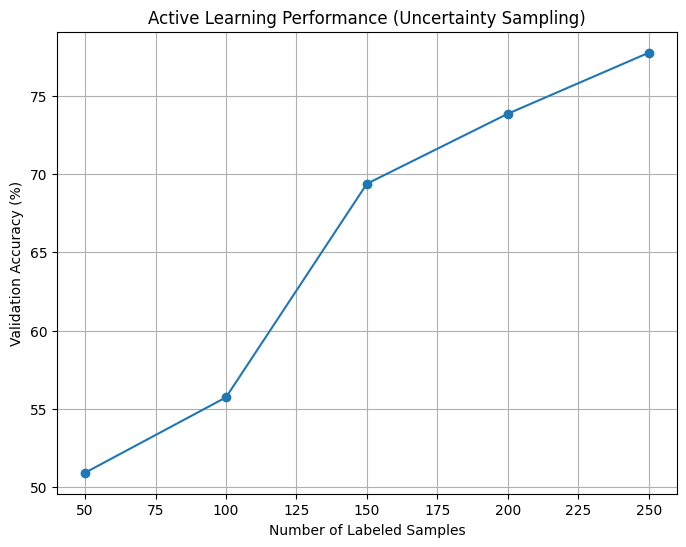

In [2]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.optim import AdamW
from datasets import load_dataset
from torch.utils.data import DataLoader, Subset
import numpy as np
import random
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

model_name = "distilbert-base-uncased"
num_labels = 2  # Binary classification

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
tokenizer = AutoTokenizer.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

train_dataset = load_dataset("glue", "sst2", split="train")
val_dataset = load_dataset("glue", "sst2", split="validation")

def collate_fn(batch):
    texts = [item["sentence"] for item in batch]
    labels = [item["label"] for item in batch]
    tokenized_inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    tokenized_inputs["labels"] = torch.tensor(labels)
    return tokenized_inputs

initial_label_size = 50
acquisition_size = 50
max_iterations = 5

all_indices = list(range(len(train_dataset)))
random.shuffle(all_indices)

labeled_indices = all_indices[:initial_label_size]
unlabeled_indices = all_indices[initial_label_size:]

labeled_sizes = []
val_accuracies = []

for iteration in range(max_iterations):
    print(f"\n=== Active Learning Iteration {iteration+1} ===")

    labeled_subset = Subset(train_dataset, labeled_indices)
    labeled_loader = DataLoader(labeled_subset, batch_size=16, shuffle=True, collate_fn=collate_fn)

    optimizer = AdamW(model.parameters(), lr=2e-5)

    model.train()
    epochs = 5
    for epoch in range(epochs):
        epoch_loss = 0
        for batch in labeled_loader:
            optimizer.zero_grad()
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch {epoch+1} Loss: {epoch_loss/len(labeled_loader):.4f}")

    val_loader = DataLoader(val_dataset, batch_size=32, collate_fn=collate_fn)
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"Validation Accuracy: {accuracy*100:.2f}%")

    labeled_sizes.append(len(labeled_indices))
    val_accuracies.append(accuracy)

    # ---------------------------------
    # Acquisition: Uncertainty Sampling
    # ---------------------------------

    if len(unlabeled_indices) == 0:
        break

    unlabeled_subset = Subset(train_dataset, unlabeled_indices)
    unlabeled_loader = DataLoader(unlabeled_subset, batch_size=32, collate_fn=collate_fn)

    uncertainties = []
    model.eval()
    with torch.no_grad():
        for batch in unlabeled_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            probabilities = torch.softmax(logits, dim=-1)
            max_probs, _ = torch.max(probabilities, dim=1)
            uncertainties.extend(1 - max_probs.cpu().numpy())  # Lower max probability = Higher uncertainty

    # Rank Unlabeled Samples by Uncertainty
    uncertain_indices = np.argsort(uncertainties)[-acquisition_size:]  # Select most uncertain
    new_indices = [unlabeled_indices[i] for i in uncertain_indices]

    labeled_indices.extend(new_indices)
    unlabeled_indices = list(set(unlabeled_indices) - set(new_indices))

    print(f"Total labeled samples after acquisition: {len(labeled_indices)}")

plt.figure(figsize=(8,6))
plt.plot(labeled_sizes, [acc*100 for acc in val_accuracies], marker='o', linestyle='-')
plt.xlabel("Number of Labeled Samples")
plt.ylabel("Validation Accuracy (%)")
plt.title("Active Learning Performance (Uncertainty Sampling)")
plt.grid(True)
plt.show()
